# Criando um modelo de regrewssão linear

- tenho os dados de preço, desconto e vou fazer uma campanha de natal nas lojas com o preço de 17.50 e desconto de até 40 centavos e preciso saber quanto de estoque eu devo mandar para a loja

In [141]:
# Importando a base de dados
# - Base de dados: 

import pandas as pd
dados = pd.read_csv("tabela_vendas.csv")

In [142]:
# Visualizando os dados

dados.head()

,ID,Registro,PrecoVenda,PrecoOriginal,Desconto,VendaQtd
0,0,1,197.74,278.84,81.10,49
1,1,2,198.00,210.54,12.54,921
2,2,3,234.83,251.26,16.43,141
3,3,4,222.81,296.67,73.86,408
4,4,5,162.80,208.15,45.35,795


In [143]:
# Visualizando informações

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             10000 non-null  int64  
 1   Registro       10000 non-null  int64  
 2   PrecoVenda     10000 non-null  float64
 3   PrecoOriginal  10000 non-null  float64
 4   Desconto       10000 non-null  float64
 5   VendaQtd       10000 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 468.9 KB


In [144]:
dados = dados.loc[dados.Desconto < 1]

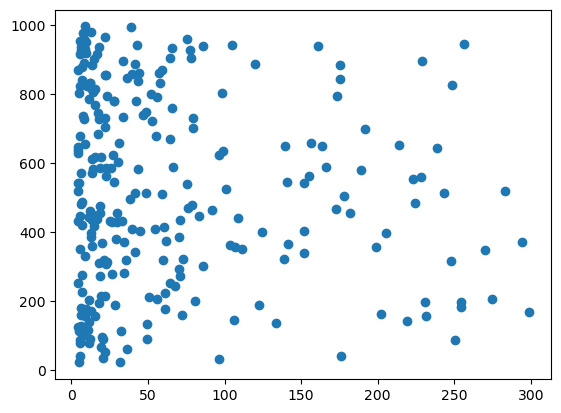

In [145]:
# Podemos fazer um scatter plot para entender a base

import matplotlib.pyplot as plt

# plot
fig, ax = plt.subplots()

x = dados.PrecoVenda
y = dados.VendaQtd

ax.scatter(x, y)

plt.show()

In [146]:
# Importando LinearRegression

from sklearn.linear_model import LinearRegression

X = x

# Fazendo o fit do modelo

reg = LinearRegression().fit(X.values.reshape(-1, 1), y)

reg.score(X.values.reshape(-1, 1), y)
## Score baixo devido aos dados pegados do gpt


0.00633969602886264

In [147]:
# Definir um lista de valores para fazer a previsão

valores = {
    'valores':[10, 50, 130, 210, 290]
}

valores = pd.DataFrame(valores)

[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
[533.21967769 532.91688399 532.6140903  532.31129661 532.00850291
 531.70570922 531.40291552 531.10012183 530.79732814 530.49453444
 530.19174075 529.88894706 529.58615336 529.28335967 528.98056598
 528.67777228 528.37497859 528.0721849  527.7693912  527.46659751
 527.16380382]


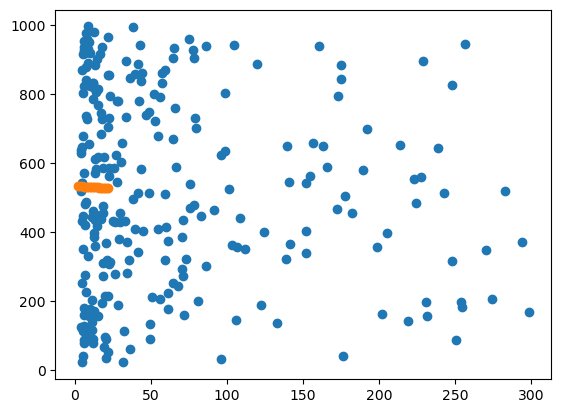

In [148]:
import matplotlib.pyplot as plt 
import numpy as np

# plot

fig, ax = plt.subplots()


ax.scatter(x, y)

x_plot = np.arange(2,23)
y_plot = reg.coef_[0]*x_plot + reg.intercept_ # Equacao da reta

print(x_plot)
print(y_plot)


ax.scatter(x_plot, y_plot)

plt.show()

In [149]:
reg.intercept_

533.8252650726618

In [150]:
# Reg Predict

reg.predict(valores)

/usr/lib/python3/dist-packages/sklearn/base.py:413: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([530.79732814, 518.6855804 , 494.46208492, 470.23858944,
       446.01509396])

In [151]:
# Escolhendo novas entradas pro modelo

# Podermos, ao inves de usar PrecoVenda, usar Preco original e Desconto

In [152]:
# Dados

X2 = dados[["PrecoOriginal", "Desconto"]]
y2 = dados.VendaQtd

reg2 = LinearRegression().fit(X2, y2)

print(reg.score(X.values.reshape(-1, 1), y))
print(reg2.score(X2, y2))

0.00633969602886264
0.006628396424683269


In [153]:
# Coeficiente Linear

reg2.coef_

array([ -0.30627718, -31.93438255])

In [154]:
reg2.intercept_


558.0005742398085

In [157]:
valores = {
    'PrecoOriginal' : [10,50,100,200,300],
    'precos' : [8, 40,80,170,260],
    'Desconto': [2,10,20,30,40]
}

valores = pd.DataFrame(valores)

reg2.predict(valores[["PrecoOriginal","Desconto"]])

array([ 491.0690373 ,  223.34288954, -111.31479516, -461.28633904,
       -811.25788293])